# **Project Title**

# Walmart
Capstone Project

**Author:** Aditi Singh

# **Problem Statement**

A retail store that has multiple outlets across the country are facing issues in managing the
inventory - to match the demand with respect to supply.

# **Objective**

1. You are provided with the weekly sales data for their various outlets. Use statistical
analysis, EDA, outlier analysis, and handle the missing values to come up with various
insights that can give them a clear perspective on the following:

a. If the weekly sales are affected by the unemployment rate, if yes - which stores
are suffering the most?

b. If the weekly sales show a seasonal trend, when and what could be the reason?

c. Does temperature affect the weekly sales in any manner?

d. How is the Consumer Price index affecting the weekly sales of various stores?

e. Top performing stores according to the historical data.

f.
The worst performing store, and how significant is the difference between the
highest and lowest performing stores.

2. Use predictive modeling techniques to forecast the sales for each store for the next 12
weeks.

# **Data Information**

* Store number

* Week of Sales    

* Sales for the given store in that week

* If it is a holiday week

* Temperature on the day of the sale

* Cost of the fuel in the region

* Consumer Price Index

* Unemployment Rate

# **Tools & Libraries**

* Pandas
* Numpy
* Matplotlib
* Plotly
* Time Series

# **Import libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Data Loading**


In [ ]:
df= pd.read_csv('/content/Walmart DataSet.csv')
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


# **Data Cleaning**

In [ ]:
df.shape

(6435, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


After examining the dataset using `df.info() `, I noticed that the Date column is stored as an object type instead of datetime. Since time-series analysis requires datetime format, I will convert this column to datetime using pandas.

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [ ]:
df.head(40)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106
5,1,2010-03-12,1439541.59,0,57.79,2.667,211.380643,8.106
6,1,2010-03-19,1472515.79,0,54.58,2.720,211.215635,8.106
7,1,2010-03-26,1404429.92,0,51.45,2.732,211.018042,8.106
8,1,2010-04-02,1594968.28,0,62.27,2.719,210.820450,7.808
9,1,2010-04-09,1545418.53,0,65.86,2.770,210.622857,7.808


In [ ]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


**1.  If the weekly sales are affected by the unemployment rate, if yes - which stores are suffering the most?**

In [ ]:
data = df[['Store', 'Weekly_Sales', 'Unemployment']].copy()
data.head()

,Store,Weekly_Sales,Unemployment
0,1,1643690.90,8.106
1,1,1641957.44,8.106
2,1,1611968.17,8.106
3,1,1409727.59,8.106
4,1,1554806.68,8.106


In [ ]:
overall_corr = data['Weekly_Sales'].corr(data['Unemployment'])
print("Overall Correlation:", overall_corr)

Overall Correlation: -0.10617608965795429


# **Interpretation**

* If value is negative → sales decrease when unemployment increases

* If value is close to 0 → weak relationship

**In this dataset:**
The correlation is slightly negative (~ -0.10)
→ Indicates a weak inverse relationship

In [ ]:
store_corr = data.groupby('Store').apply(
    lambda x: x['Weekly_Sales'].corr(x['Unemployment'])
).reset_index(name='Correlation')

store_corr = store_corr.sort_values(by='Correlation')

store_corr.head(10)

/tmp/ipykernel_10066/752991508.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  store_corr = data.groupby('Store').apply(


,Store,Correlation
37,38,-0.785290
43,44,-0.780076
38,39,-0.384681
41,42,-0.356355
40,41,-0.350630
3,4,-0.337015
16,17,-0.263600
2,3,-0.230413
36,37,-0.221287
4,5,-0.207043


Stores at the top have strong negative correlation

These stores are more affected by unemployment

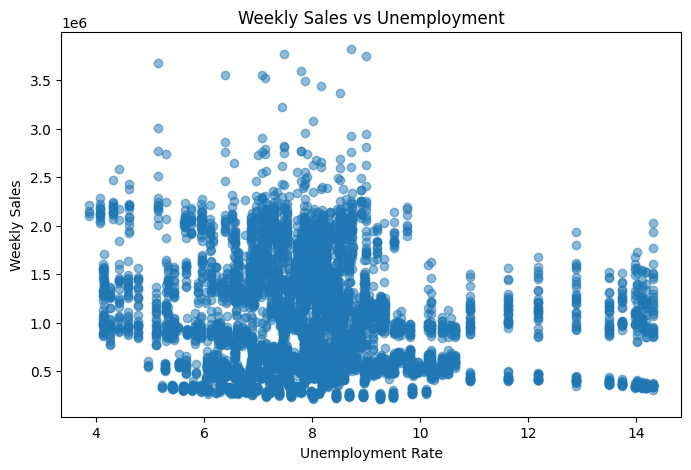

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(data['Unemployment'], data['Weekly_Sales'], alpha=0.5)
plt.xlabel("Unemployment Rate")
plt.ylabel("Weekly Sales")
plt.title("Weekly Sales vs Unemployment")
plt.show()

The scatter plot between weekly sales and unemployment rate shows a slight downward trend. The data points are widely scattered, indicating that the relationship is weak. However, as unemployment increases, weekly sales tend to decrease slightly. This suggests a weak negative relationship between unemployment and sales.

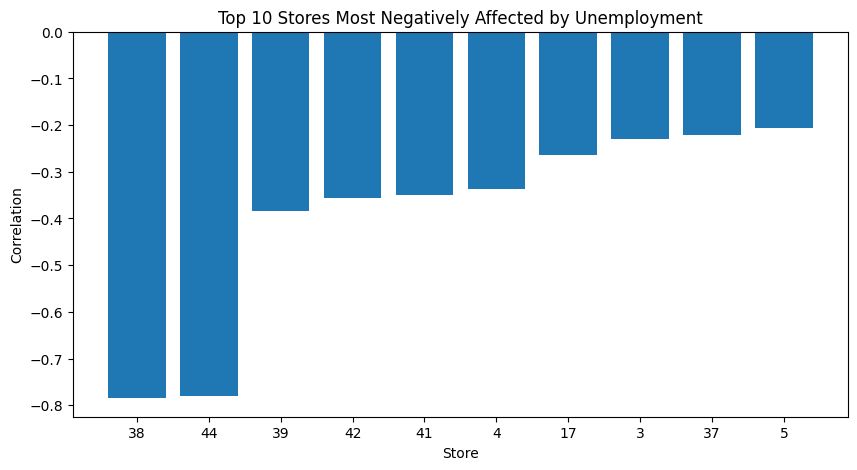

In [ ]:
store_corr_sorted = store_corr.sort_values(by='Correlation').head(10)

plt.figure(figsize=(10,5))
plt.bar(store_corr_sorted['Store'].astype(str), store_corr_sorted['Correlation'])
plt.xlabel("Store")
plt.ylabel("Correlation")
plt.title("Top 10 Stores Most Negatively Affected by Unemployment")
plt.show()

The bar chart shows the top 10 stores with the most negative correlation between unemployment and weekly sales. Stores at the left side (like Store 38 and Store 44) have the strongest negative correlation, indicating that these stores are more affected by unemployment. As unemployment increases, their sales decrease more significantly compared to other stores.

# Conclusion
To analyze the impact of unemployment on weekly sales, correlation analysis was performed. The overall correlation between weekly sales and unemployment rate is slightly negative (-0.106), indicating a weak inverse relationship. This means that as unemployment increases, weekly sales tend to decrease slightly.

Further store-level analysis reveals that the impact is not uniform across all stores. Some stores show a stronger negative relationship. In particular, Store 38 and Store 44 exhibit the highest negative correlation, indicating that these stores are most affected by rising unemployment.

Therefore, it can be concluded that unemployment does affect weekly sales, but the impact is relatively weak overall and more significant for certain stores.

However, the weak correlation suggests that other factors such as holidays, seasonal trends, and economic conditions may also play a significant role in influencing weekly sales.

**b.  If the weekly sales show a seasonal trend, when and what could be the reason?**

In [ ]:
df['Month'] = df['Date'].dt.month

In [ ]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean().reset_index()
monthly_sales

,Month,Weekly_Sales
0,1,9.238846e+05
1,2,1.053200e+06
2,3,1.013309e+06
3,4,1.026762e+06
4,5,1.031714e+06
5,6,1.064325e+06
6,7,1.031748e+06
7,8,1.048017e+06
8,9,9.893353e+05
9,10,9.996321e+05


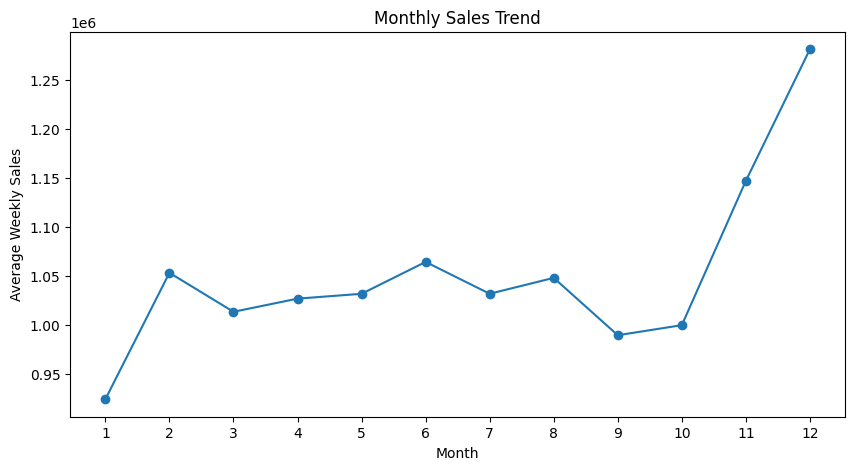

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Month'], monthly_sales['Weekly_Sales'], marker='o')
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.title("Monthly Sales Trend")
plt.xticks(range(1,13))
plt.show()

The line chart shows a clear seasonal pattern in weekly sales. Sales tend to increase significantly during the end of the year, especially in November and December. After that, sales decline in the early months of the year and remain relatively stable during the middle months.

# Reason Behind Seasonality


The increase in sales during November and December is likely due to major holiday seasons such as Christmas, New Year, and promotional events like Black Friday. Customers tend to spend more during this period, leading to higher sales. On the other hand, sales decline in the early months of the year as consumer spending reduces after the holiday season.

In [ ]:
df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

,Weekly_Sales
Holiday_Flag,
0,1.041256e+06
1,1.122888e+06


Sales during holidays are generally higher compared to non-holiday periods.

# Conclusion
The analysis shows that weekly sales exhibit a clear seasonal trend. Sales peak during November and December, likely due to holiday seasons and increased consumer spending. In contrast, sales are lower in the early months of the year. This indicates that seasonality plays a significant role in influencing weekly sales patterns.

**c. Does temperature affect the weekly sales in any manner?**

In [ ]:
temp_data = df[['Weekly_Sales', 'Temperature']].copy()
temp_data.head()

,Weekly_Sales,Temperature
0,1643690.90,42.31
1,1641957.44,38.51
2,1611968.17,39.93
3,1409727.59,46.63
4,1554806.68,46.50


In [ ]:
temp_corr = temp_data['Weekly_Sales'].corr(temp_data['Temperature'])
print("Correlation between Temperature and Weekly Sales:", temp_corr)

Correlation between Temperature and Weekly Sales: -0.06381001317946956


The correlation between temperature and weekly sales is very weak, as the value is close to zero. This indicates that temperature does not have a significant impact on weekly sales.

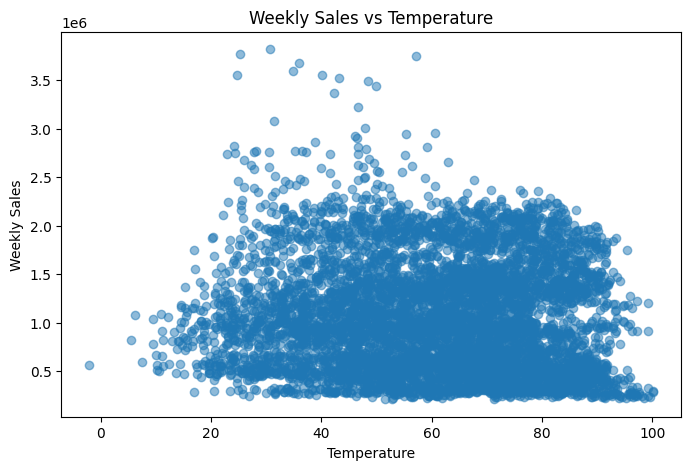

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(temp_data['Temperature'], temp_data['Weekly_Sales'], alpha=0.5)
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")
plt.title("Weekly Sales vs Temperature")
plt.show()

The scatter plot shows no clear pattern between temperature and weekly sales. The data points are widely distributed, indicating that changes in temperature do not significantly influence sales.
# Conclusion

The analysis shows that temperature does not significantly affect weekly sales. Both the correlation value and scatter plot indicate a weak relationship between the two variables. Therefore, temperature is not a major factor influencing sales performance in this dataset.

**d. How is the Consumer Price index affecting the weekly sales of various stores?**

In [ ]:
cpi_data = df[['Store', 'Weekly_Sales', 'CPI']].copy()
cpi_data.head()

,Store,Weekly_Sales,CPI
0,1,1643690.90,211.096358
1,1,1641957.44,211.242170
2,1,1611968.17,211.289143
3,1,1409727.59,211.319643
4,1,1554806.68,211.350143


In [ ]:
overall_cpi_corr = cpi_data['Weekly_Sales'].corr(cpi_data['CPI'])
print("Overall Correlation between CPI and Weekly Sales:", overall_cpi_corr)

Overall Correlation between CPI and Weekly Sales: -0.07263416204017631


The overall correlation between CPI and weekly sales is expected to be weak (close to zero), indicating that CPI does not strongly influence sales at a global level.

In [ ]:
store_cpi_corr = cpi_data.groupby('Store').apply(
    lambda x: x['Weekly_Sales'].corr(x['CPI'])
).reset_index(name='Correlation')

store_cpi_corr = store_cpi_corr.sort_values(by='Correlation')

store_cpi_corr.head(10)

/tmp/ipykernel_10066/3083837731.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  store_cpi_corr = cpi_data.groupby('Store').apply(


,Store,Correlation
35,36,-0.915095
34,35,-0.424107
13,14,-0.419755
29,30,-0.298188
42,43,-0.285686
26,27,-0.213082
17,18,-0.193541
14,15,-0.174467
20,21,-0.163649
18,19,-0.155341


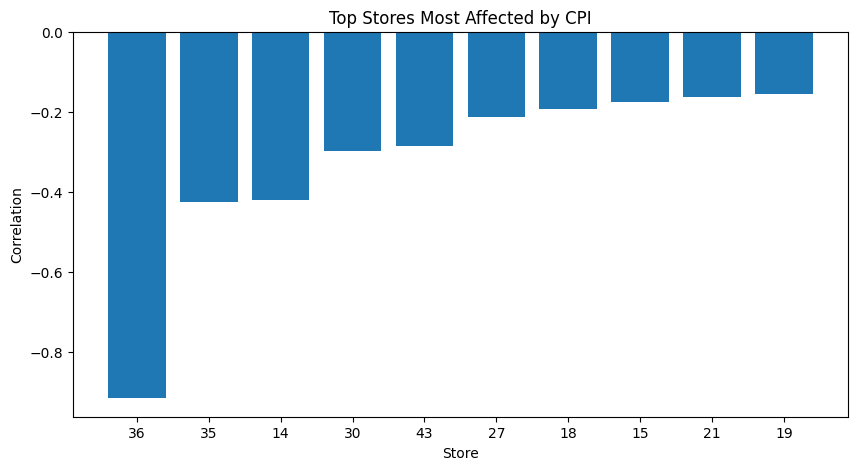

In [ ]:
top_cpi_affected = store_cpi_corr.sort_values(by='Correlation').head(10)

plt.figure(figsize=(10,5))
plt.bar(top_cpi_affected['Store'].astype(str), top_cpi_affected['Correlation'])
plt.xlabel("Store")
plt.ylabel("Correlation")
plt.title("Top Stores Most Affected by CPI")
plt.show()

The bar chart shows that some stores have slightly negative or positive correlations with CPI. However, most values are close to zero, indicating that CPI does not significantly affect weekly sales across most stores.
# Conclusion

The analysis indicates that CPI has a weak impact on weekly sales. The overall correlation between CPI and sales is close to zero, suggesting no strong relationship. Store-level analysis also shows that most stores exhibit weak correlations, with only a few showing slight positive or negative trends. Therefore, CPI is not a major factor influencing weekly sales in this dataset.

**e. Top performing stores according to the historical data.**

In [ ]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum().reset_index()
store_sales.head()

,Store,Weekly_Sales
0,1,2.224028e+08
1,2,2.753824e+08
2,3,5.758674e+07
3,4,2.995440e+08
4,5,4.547569e+07


In [ ]:
top_stores = store_sales.sort_values(by='Weekly_Sales', ascending=False)
top_stores.head(10)

,Store,Weekly_Sales
19,20,3.013978e+08
3,4,2.995440e+08
13,14,2.889999e+08
12,13,2.865177e+08
1,2,2.753824e+08
9,10,2.716177e+08
26,27,2.538559e+08
5,6,2.237561e+08
0,1,2.224028e+08
38,39,2.074455e+08


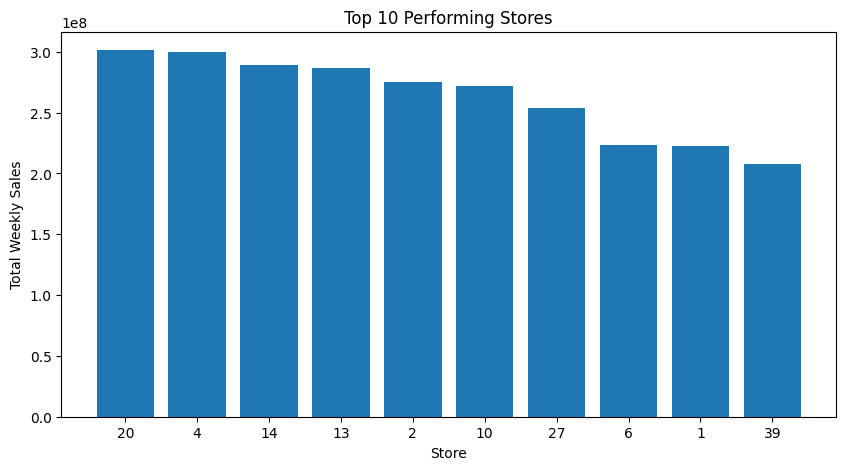

In [ ]:
top10 = top_stores.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10['Store'].astype(str), top10['Weekly_Sales'])
plt.xlabel("Store")
plt.ylabel("Total Weekly Sales")
plt.title("Top 10 Performing Stores")
plt.show()

# Conclusion

Based on historical sales data, the top performing stores were identified by aggregating total weekly sales. The analysis shows that a few stores consistently generate significantly higher revenue than others. Stores such as Store 20, Store 4, and Store 14 are among the top performers. This indicates that these stores have strong customer demand and better overall performance compared to other stores.

**f. the worst performing store and how significant is the difference between the highest and lowest performing stores.**

In [ ]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum().reset_index()

In [ ]:
# Best performing store
best_store = store_sales.loc[store_sales['Weekly_Sales'].idxmax()]

# Worst performing store
worst_store = store_sales.loc[store_sales['Weekly_Sales'].idxmin()]

print("Best Store:\n", best_store)
print("\nWorst Store:\n", worst_store)

Best Store:
 Store           2.000000e+01
Weekly_Sales    3.013978e+08
Name: 19, dtype: float64

Worst Store:
 Store                 33.00
Weekly_Sales    37160221.96
Name: 32, dtype: float64


In [ ]:
difference = best_store['Weekly_Sales'] - worst_store['Weekly_Sales']

print("Difference in Sales:", difference)

Difference in Sales: 264237570.49999997


In [ ]:
percentage_diff = (difference / best_store['Weekly_Sales']) * 100

print("Percentage Difference:", percentage_diff)

Percentage Difference: 87.67070533042084


The percentage difference highlights how large the gap is, showing that the best store outperforms the worst store by a considerable margin.

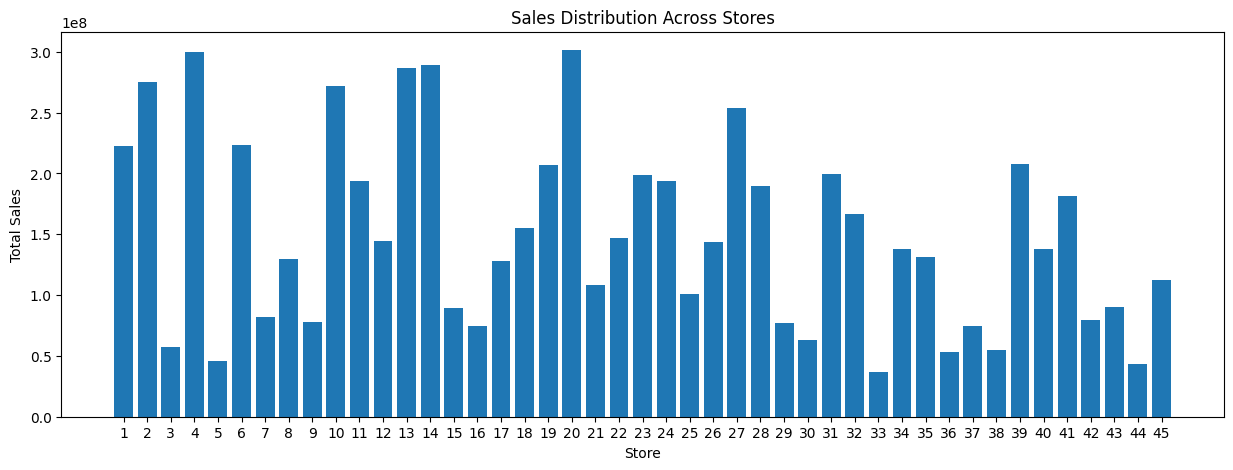

In [ ]:
plt.figure(figsize=(15,5))
plt.bar(store_sales['Store'].astype(str), store_sales['Weekly_Sales'])
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.title("Sales Distribution Across Stores")
plt.show()

# Conclusion
The analysis identifies the worst performing store as the one with the lowest total weekly sales. A comparison with the top performing store reveals a significant gap in performance. This indicates that sales are not evenly distributed across stores, and certain stores contribute much more to overall revenue. The large difference suggests that factors such as location, customer demand, and store size may play a crucial role in store performance.

2. Use predictive modeling techniques to forecast the sales for each store for the next 12 weeks.

In [ ]:
df.set_index('Date', inplace=True)
# There are about 45 different stores in this dataset. Lets select the any store id from 1-45
a= int(input("Enter the store id:"))
store = df[df.Store == a]
sales = pd.DataFrame(store.Weekly_Sales.groupby(store.index).sum())
sales.dtypes

Enter the store id:6


,0
Weekly_Sales,float64


In [ ]:
sales.head(20)

,Weekly_Sales
Date,
2010-02-05,1652635.10
2010-02-12,1606283.86
2010-02-19,1567138.07
2010-02-26,1432953.21
2010-03-05,1601348.82
2010-03-12,1558621.36
2010-03-19,1693058.91
2010-03-26,1472033.38
2010-04-02,1770333.90


In [ ]:
#remove date from index to change its dtype because it clearly isnt acceptable.
sales.reset_index(inplace = True)
#converting 'date' column to a datetime type
sales['Date'] = pd.to_datetime(sales['Date'])
# resetting date back to the index
sales.set_index('Date',inplace = True)

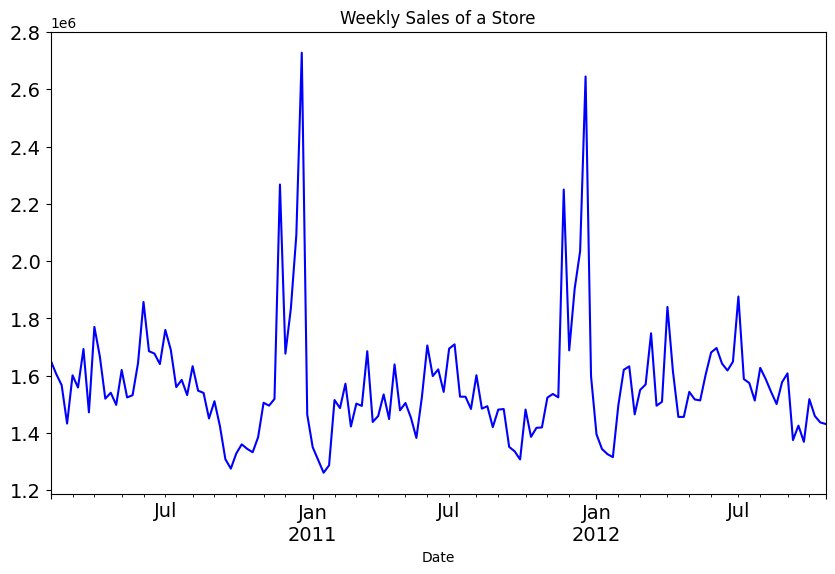

In [ ]:
import matplotlib.dates as mdates
sales.Weekly_Sales.plot(figsize=(10,6), title= 'Weekly Sales of a Store', fontsize=14, color = 'blue')
plt.show()

<Figure size 640x480 with 0 Axes>

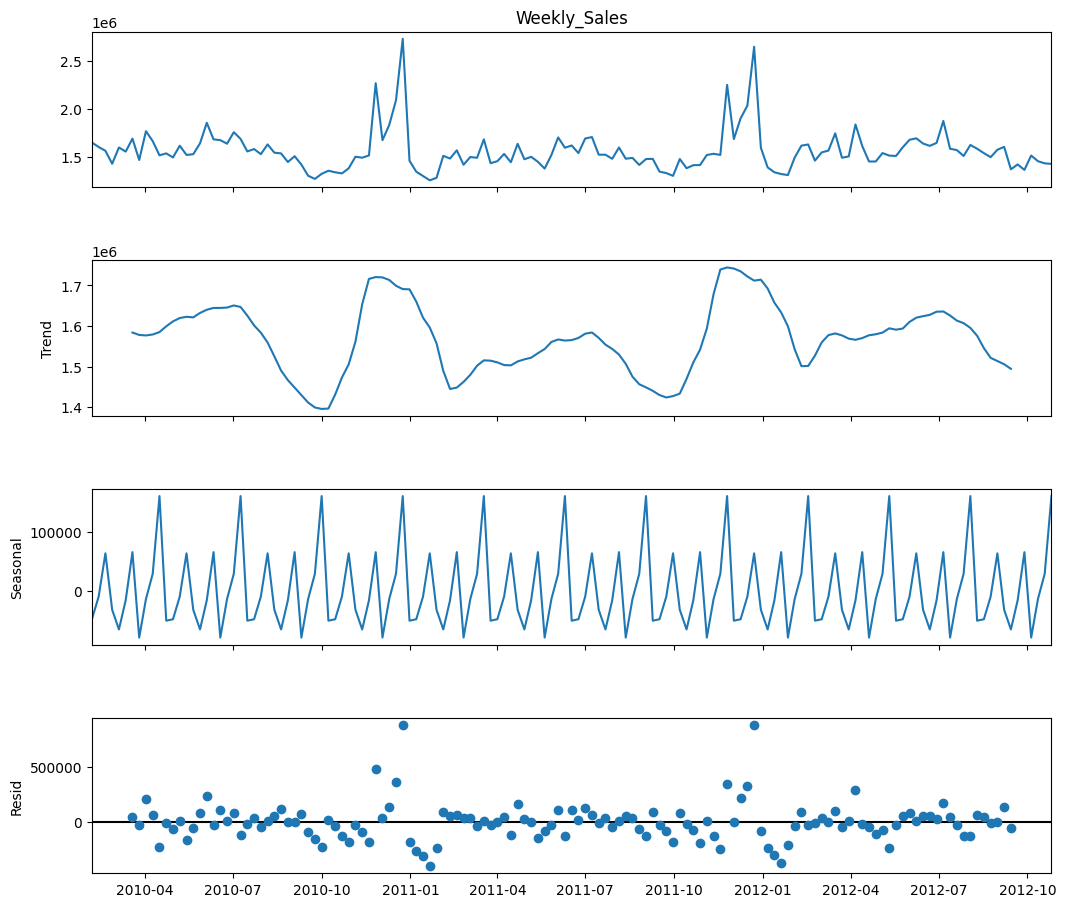

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(sales.Weekly_Sales, period=12)
fig = plt.figure()
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.show()

In [ ]:
#lets compare the 2012 data of two stores
# Lets take store 5 data for analysis
store5 = df[df.Store == 5]
# there are about 45 different stores in this dataset.

sales5 = pd.DataFrame(store5.Weekly_Sales.groupby(store5.index).sum())
sales5.dtypes
# Grouped weekly sales by store 6

#remove date from index to change its dtype because it clearly isnt acceptable.
sales5.reset_index(inplace = True)

#converting 'date' column to a datetime type
sales5['Date'] = pd.to_datetime(sales5['Date'])
# resetting date back to the index
sales5.set_index('Date',inplace = True)

In [ ]:
y1=sales.Weekly_Sales
y2=sales5.Weekly_Sales

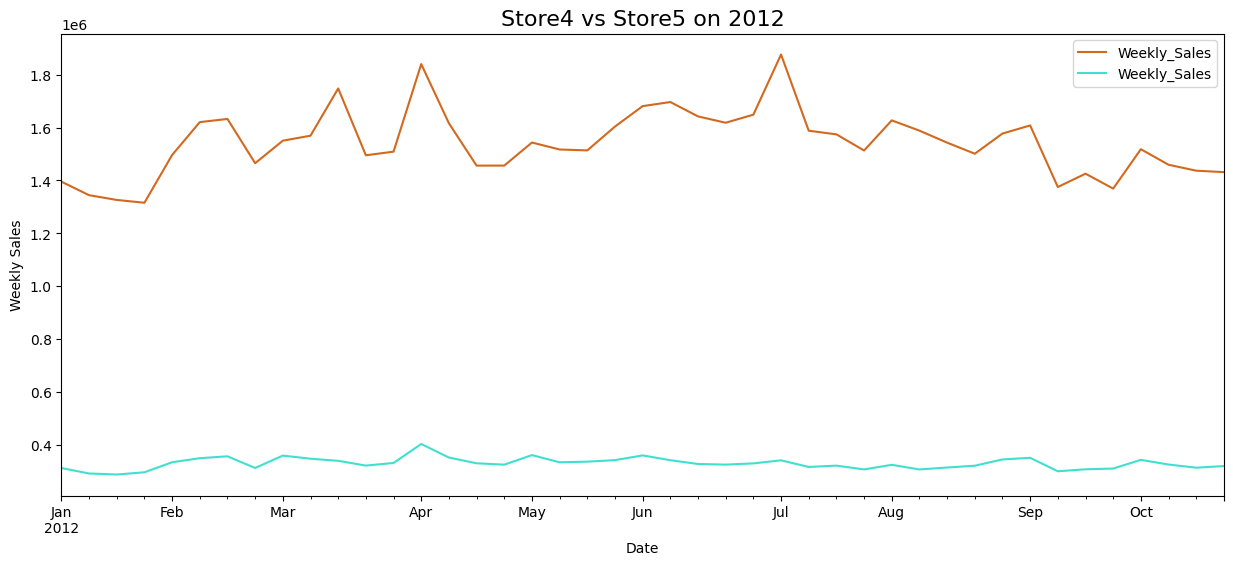

In [ ]:
y1['2012'].plot(figsize=(15, 6),legend=True, color = 'chocolate')
y2['2012'].plot(figsize=(15, 6), legend=True, color = 'turquoise')
plt.ylabel('Weekly Sales')
plt.xlabel("Date")
plt.title('Store4 vs Store5 on 2012', fontsize = '16')
plt.show()

In [ ]:
# Clearly we can see the irregularities

In [ ]:
# Define the p, d and q parameters to take any value between 0 and 2
p = d = q = range(0, 5)
import itertools
# Generate all different combinations of p, d and q triplets
pdq = list(itertools.product(p, d, q))

# Generate all different combinations of seasonal p, d and q triplets
seasonal_pdq = [(x[0], x[1], x[2], 52) for x in list(itertools.product(p, d, q))]

In [ ]:
import statsmodels.api as sm

mod = sm.tsa.statespace.SARIMAX(y1,
                                order=(4, 4, 3),
                                seasonal_order=(1, 1, 0, 52),   #enforce_stationarity=False,
                                enforce_invertibility=False)

results = mod.fit()

print(results.summary().tables[1])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.3978      1.294     -1.080      0.280      -3.934       1.138
ar.L2         -1.0589      1.127     -0.939      0.348      -3.268       1.150
ar.L3         -0.5515      0.697     -0.791      0.429      -1.917       0.815
ar.L4         -0.1648      0.267     -0.617      0.537      -0.688       0.358
ma.L1         -1.5015      1.274     -1.179      0.238      -3.998       0.995
ma.L2          0.0578      2.596      0.022      0.982      -5.029       5.145
ma.L3          0.4487      1.337      0.336      0.737      -2.172       3.069
ar.S.L52      -0.1058      0.069     -1.523      0.128      -0.242       0.030
sigma2      1.801e+10   6.21e-10    2.9e+19      0.000     1.8e+10     1.8e+10


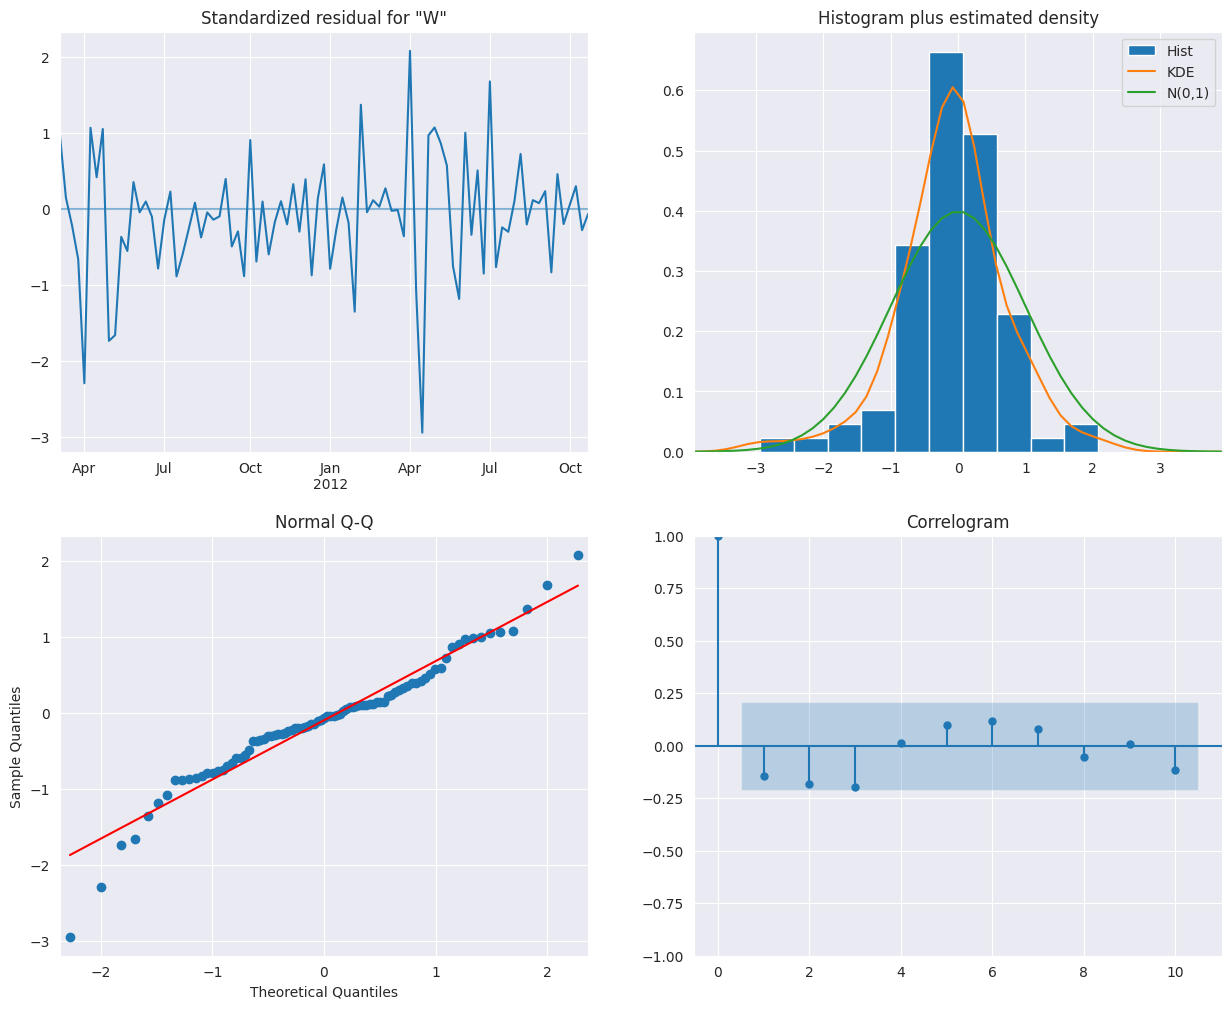

In [ ]:
sns.set_style('darkgrid')
results.plot_diagnostics(figsize=(15, 12))
plt.show()

In [ ]:
pred = results.get_prediction(start=pd.to_datetime('2012-07-27'), dynamic=False)
pred_ci = pred.conf_int()

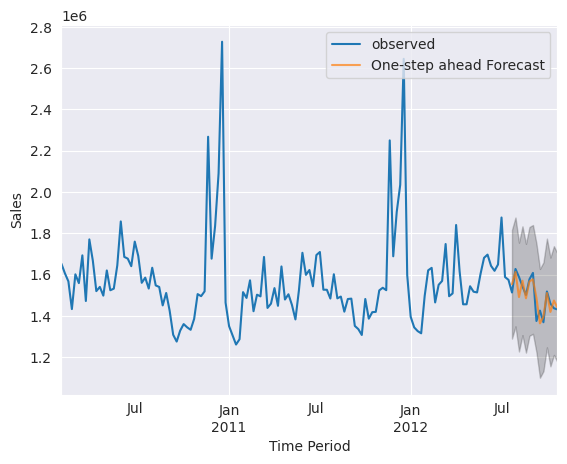

In [ ]:
ax = y1['2010':].plot(label='observed')
pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.7)

ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.2)

ax.set_xlabel('Time Period')
ax.set_ylabel('Sales')
plt.legend()

plt.show()

In [ ]:
y_forecasted = pred.predicted_mean
y_truth = y1['2012-7-27':]

# Compute the mean square error
mse = ((y_forecasted - y_truth) ** 2).mean()
print('The Mean Squared Error of our forecasts is {}'.format(round(mse, 2)))

The Mean Squared Error of our forecasts is 2395857571.28


In [ ]:
pred_dynamic = results.get_prediction(start=pd.to_datetime('2012-7-27'), dynamic=True, full_results=True)
pred_dynamic_ci = pred_dynamic.conf_int()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['full_results']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


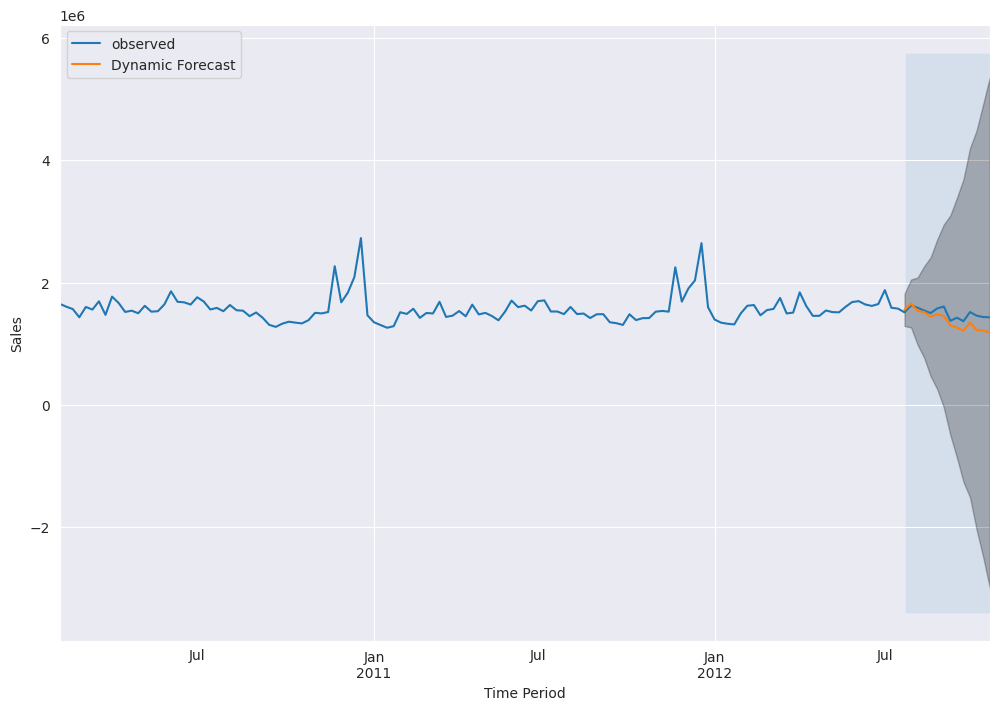

In [ ]:
ax = y1['2010':].plot(label='observed', figsize=(12, 8))
pred_dynamic.predicted_mean.plot(label='Dynamic Forecast', ax=ax)

ax.fill_between(pred_dynamic_ci.index,
                pred_dynamic_ci.iloc[:, 0],
                pred_dynamic_ci.iloc[:, 1], color='k', alpha=.25)

ax.fill_betweenx(ax.get_ylim(), pd.to_datetime('2012-7-26'), y1.index[-1],
                 alpha=.1, zorder=-1)

ax.set_xlabel('Time Period')
ax.set_ylabel('Sales')

plt.legend()
plt.show()

In [ ]:
# Extract the predicted and true values of our time series
y_forecasted = pred_dynamic.predicted_mean
print(y_forecasted)

2012-07-27    1.553430e+06
2012-08-03    1.657291e+06
2012-08-10    1.533914e+06
2012-08-17    1.519349e+06
2012-08-24    1.440943e+06
2012-08-31    1.481085e+06
2012-09-07    1.454507e+06
2012-09-14    1.302865e+06
2012-09-21    1.261627e+06
2012-09-28    1.214840e+06
2012-10-05    1.343623e+06
2012-10-12    1.224510e+06
2012-10-19    1.215326e+06
2012-10-26    1.183300e+06
Freq: W-FRI, Name: predicted_mean, dtype: float64


In [ ]:
y_truth = y1['2012-7-27':]

print(y_truth)

Date
2012-07-27    1513229.16
2012-08-03    1627274.93
2012-08-10    1588380.73
2012-08-17    1543049.52
2012-08-24    1501095.49
2012-08-31    1577439.81
2012-09-07    1608077.01
2012-09-14    1375166.86
2012-09-21    1425603.65
2012-09-28    1369131.46
2012-10-05    1518177.71
2012-10-12    1459396.84
2012-10-19    1436883.99
2012-10-26    1431426.34
Name: Weekly_Sales, dtype: float64


In [ ]:
# Compute the Root mean square error
rmse = np.sqrt(((y_forecasted - y_truth) ** 2).mean())
print('The Root Mean Squared Error of our forecasts is {}'.format(round(rmse, 2)))

The Root Mean Squared Error of our forecasts is 145098.4


In [ ]:
Residual= y_forecasted - y_truth
print("Residual for Store1",np.abs(Residual).sum())

Residual for Store1 1728159.0517342598


In [ ]:
# Get forecast 12 weeks ahead in future
pred_uc = results.get_forecast(steps=12)

print(pred_uc)

In [ ]:
# Get confidence intervals of forecasts
pred_ci = pred_uc.conf_int()

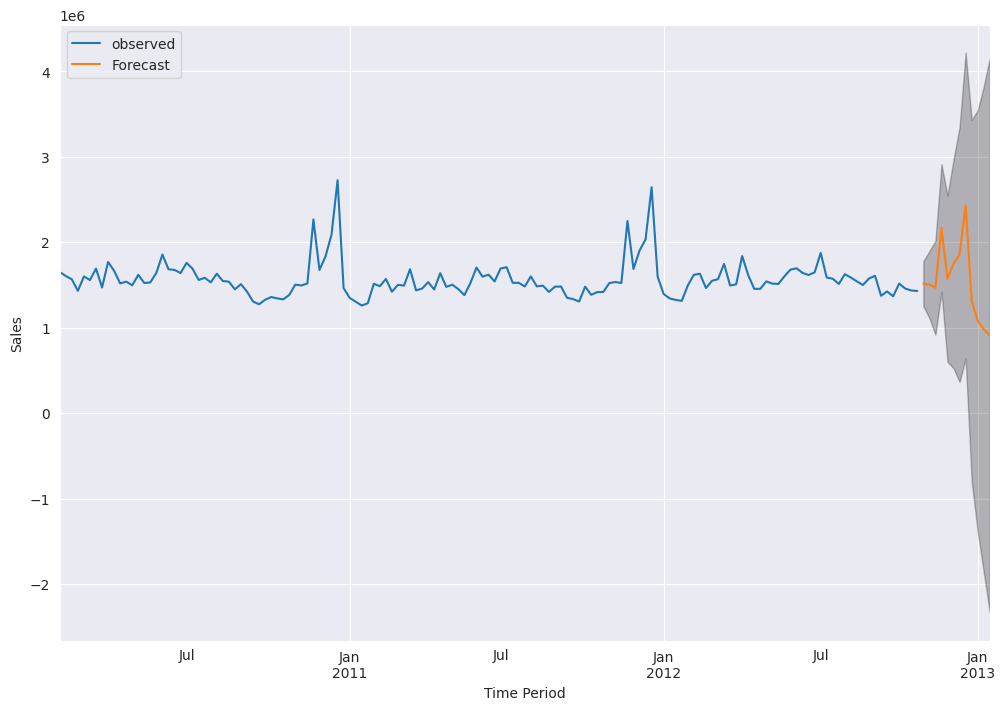

In [ ]:
ax = y1.plot(label='observed', figsize=(12, 8))
pred_uc.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.25)
ax.set_xlabel('Time Period')
ax.set_ylabel('Sales')

plt.legend()
plt.show()

In [57]:
forecast = results.get_forecast(steps=12)

forecast_df = pd.DataFrame({
    'Date': forecast.predicted_mean.index,
    'Forecasted Sales': forecast.predicted_mean.values,
    'Lower CI': forecast.conf_int().iloc[:, 0].values,
    'Upper CI': forecast.conf_int().iloc[:, 1].values
})

print(forecast_df)

         Date  Forecasted Sales      Lower CI      Upper CI
0  2012-11-02      1.516841e+06  1.253536e+06  1.780146e+06
1  2012-11-09      1.505920e+06  1.113937e+06  1.897903e+06
2  2012-11-16      1.469124e+06  9.203225e+05  2.017925e+06
3  2012-11-23      2.168142e+06  1.421576e+06  2.914708e+06
4  2012-11-30      1.574696e+06  6.024956e+05  2.546897e+06
5  2012-12-07      1.748704e+06  5.279560e+05  2.969452e+06
6  2012-12-14      1.857151e+06  3.668295e+05  3.347472e+06
7  2012-12-21      2.430839e+06  6.410050e+05  4.220674e+06
8  2012-12-28      1.319730e+06 -7.934155e+05  3.432875e+06
9  2013-01-04      1.081581e+06 -1.380924e+06  3.544087e+06
10 2013-01-11      9.835349e+05 -1.855039e+06  3.822109e+06
11 2013-01-18      9.121040e+05 -2.330222e+06  4.154430e+06
